In [1]:
from gpu_odes.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [167]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wa', 6.0e9*2*pi)
sim.add_param('wb', 3.8e9*2*pi)
sim.add_param('sqrtka', np.sqrt(20e6*2*pi)) # in MHz
sim.add_param('sqrtkb', np.sqrt(30e6*2*pi)) # in MHz
sim.add_param('gab', 10e6 * 2 * np.pi)
sim.add_param('gbc', 10e6 * 2 * np.pi)
sim.add_param('g3', 50e6 * 2 * np.pi)
sim.add_param('g4', 10e6 * 2 * np.pi)
sim.add_param('gr', 1e6 * 2 * np.pi)
sim.add_param('amplR',  20000)
sim.add_param('amplC1', 0)
sim.add_paramsweep('wR', 5.8e9 * 2 * np.pi, 6.2e9 * 2 * np.pi, 201, is_excitation=True)
sim.add_paramsweep('wC1', -2.4e9*2*np.pi,  -2.0e9*2*np.pi, 201)
sim.add_param('rampR', 1e-9)
sim.add_param('rampC1', 1e-9)
sim.add_param('startR', 5e-9)
sim.add_param('stopR', 200e-9)
sim.add_param('startC1', 5e-9)
sim.add_param('stopC1', 200e-9)
sim.add_param('phaseR', -np.pi / 4)
sim.add_param('phaseC1', np.pi / 3)

Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')
C1pulse = sim.make_pulse('wC1', 'amplC1', 'phaseC1', 'startC1', 'stopC1', 'rampC1')

sim.add_EOM('bin', C1pulse)
sim.add_EOM('ain', Rpulse)

sim.add_EOM('a', '-1j*wa*a - 1j*gab*b*conjugate(bin) - ain*sqrtka - (sqrtka**2/2)*a')
sim.add_EOM('b', '-1j*wb*b - 1j*gab*a*bin - 1j*b*g4*abs(b)**2 - bin*sqrtkb - (sqrtkb**2/2)*b ')
sim.set_solve_type('decimate')

sim.specify_time(10, 1000, d_factor=1)

sim.validate()

Simulation validation success!


there's a bug, where the size of different sweeps get mixed up, so you can only run square sweeps

Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


C:\Users\boris\AppData\Local\Temp\ipykernel_20388\2797698901.py:5: RuntimeWarning: invalid value encountered in divide
  plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='3WM drive')
C:\Users\boris\AppData\Local\Temp\ipykernel_20388\2797698901.py:8: RuntimeWarning: invalid value encountered in divide
  plt.plot(t*1e9, x[6,:]/np.max(x[6,:])+6,color=(0,0,1,0.5),label='b mode')


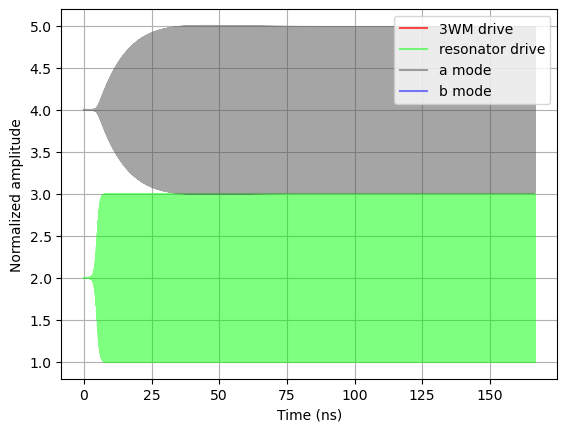

In [168]:
x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='3WM drive')
plt.plot(t*1e9, x[2,:]/np.max(x[2,:])+2,color=(0,1,0,0.5),label='resonator drive')
plt.plot(t*1e9, x[4,:]/np.max(x[4,:])+4,color=(0.3,0.3,0.3,0.5),label='a mode')
plt.plot(t*1e9, x[6,:]/np.max(x[6,:])+6,color=(0,0,1,0.5),label='b mode')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()
plt.show()

In [169]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:19<00:00, 511.68it/s]


 
...finished GPU solve!


In [170]:
Id = I.copy()
Qd = Q.copy()
td = t.copy()

In [171]:
ain = Id[2,:]+1j*Qd[2,:]
binn = Id[0,:]+1j*Qd[0,:]
a = Id[4,:]+1j*Qd[4,:]
b = Id[6,:]+1j*Qd[6,:]

aout = ain + sim.param_dict['sqrtka']*a

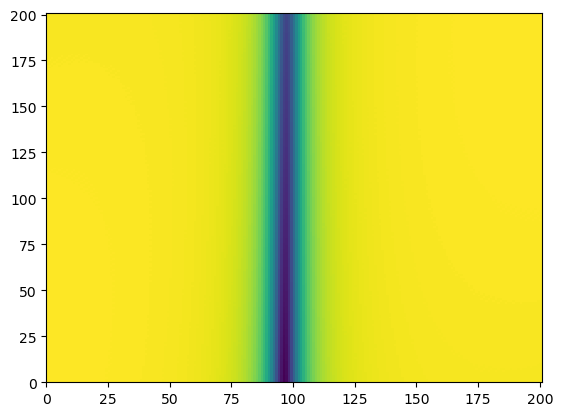

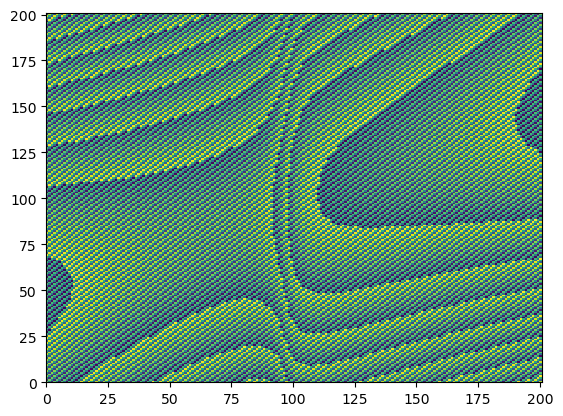

In [172]:
steady_state_aout = np.mean(np.abs(aout[:,:,np.shape(td)[-1]//2:]), axis=-1)

plt.pcolor(np.abs(steady_state_aout).transpose())
plt.show()
plt.pcolor(np.angle(aout[:,:,-1]).transpose())
plt.show()

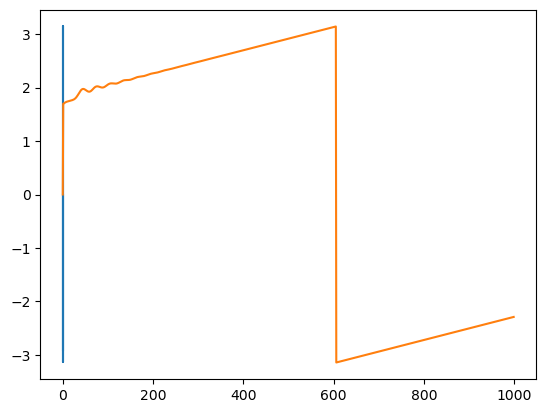

In [179]:

plt.plot(td[0,0,:], np.angle(a[0,0,:]))
plt.plot(np.angle(aout[0,1,:]))
# plt.plot(np.angle(aout[1,0,:]))
plt.show()